# **Dataset**

In [ ]:
# load dataset
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
drug_reviews_druglib_com = fetch_ucirepo(id=461)

# data (as pandas dataframes)
X = drug_reviews_druglib_com.data.features

# metadata
print(drug_reviews_druglib_com.metadata)

# variable information
print(drug_reviews_druglib_com.variables)


{'uci_id': 461, 'name': 'Drug Reviews (Druglib.com)', 'repository_url': 'https://archive.ics.uci.edu/dataset/461/drug+review+dataset+druglib+com', 'data_url': 'https://archive.ics.uci.edu/static/public/461/data.csv', 'abstract': 'The dataset provides patient reviews on specific drugs along with related conditions. Reviews and ratings are grouped into reports on the three aspects benefits, side effects and overall comment.', 'area': 'Health and Medicine', 'tasks': ['Classification', 'Regression', 'Clustering'], 'characteristics': ['Multivariate', 'Text'], 'num_instances': 4143, 'num_features': 8, 'feature_types': ['Integer'], 'demographics': [], 'target_col': None, 'index_col': ['reviewID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2018, 'last_updated': 'Wed Apr 03 2024', 'dataset_doi': '10.24432/C55G6J', 'creators': ['Surya Kallumadi', 'Felix Grer'], 'intro_paper': {'ID': 457, 'type': 'NATIVE', 'title': 'Aspect-Based Sentiment Analysis of D

# **Preprocessing**
From the dataset, we can have:
*   `benefitsReview` → Benefit aspect
*   `sideEffectsReview` → Side Effects aspect
*   `commentsReview` → General/Overall aspect

Also:
*   `effectiveness` (categorical: Highly Effective, Marginally Effective, etc.) → sentiment label for benefits
*   `sideEffects` (categorical: Severe, Mild, None) → sentiment label for side effects

In [ ]:
# Clean Reviews
import unicodedata, re

def basic_clean(s: str) -> str:
    if not isinstance(s, str):
        return ""
    s = unicodedata.normalize("NFKC", s)
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)                       # collapse spaces
    s = re.sub(r"(.)\1{2,}", r"\1\1\1", s)           # cooool -> coool
    s = re.sub(r"http\S+|www\.\S+", "<url>", s)      # URLs
    s = re.sub(r"@\w+", "<user>", s)                 # handles
    s = re.sub(r"\b\d+(\.\d+)?\b", "<num>", s)       # numbers -> <num>
    # keep ! ? ' for negation/sentiment
    return s

In [ ]:
# Map numeric ratings → sentiment (neg, neu, pos)
#def map_rating(r):
#    if r <= 4: return "negative"
#    elif r <= 6: return "neutral"
#    else: return "positive"

#X['sentiment'] = X['rating'].apply(map_rating)

## comments recall for NEUTRAL ~ 0.03 so wide the band for neutral(4~7)

In [ ]:
# Map numeric ratings → sentiment (neg, neu, pos)
# second try
def map_rating(r):
    if r <= 3:    return "negative"
    elif r <= 7:  return "neutral"
    elif r <= 10: return "positive"
    else: return None

X['sentiment'] = X['rating'].apply(map_rating)

In [ ]:
# simple mapping
def map_side_effects(val):
    if "No Side Effects" in val:                  return "positive"
    elif "Mild Side Effects" in val:              return "neutral"
    elif "Moderate Side Effects" in val:          return "negative"
    elif "Severe Side Effects" in val:            return "negative"
    elif "Extremely Severe Side Effects" in val:  return "negative"
    else: return None

X['side_sentiment'] = X['sideEffects'].apply(map_side_effects)

In [ ]:
# simple mapping
def map_effectiveness(val):
    if "Highly Effective" in val:           return "positive"
    elif "Considerably Effective" in val:   return "positive"
    elif "Moderately Effective" in val:     return "neutral"
    elif "Marginally Effective" in val:     return "neutral"
    elif "Ineffective" in val:              return "negative"
    else: return None

X['benefit_sentiment'] = X['effectiveness'].apply(map_effectiveness)

In [ ]:
df = X.copy()

df['comments_clean'] = df['commentsReview'].apply(basic_clean)
df['benefits_clean'] = df['benefitsReview'].apply(basic_clean)
df['side_clean']     = df['sideEffectsReview'].apply(basic_clean)


df['label_comments'] = df['rating'].apply(map_rating)
df['label_benefits'] = df['effectiveness'].apply(map_effectiveness)
df['label_side']     = df['sideEffects'].apply(map_side_effects)

df = df.dropna(subset=['comments_clean','benefits_clean','side_clean',
                       'label_comments','label_benefits','label_side']).reset_index(drop=True)


# **Train Models**

(C) Transformers (DistilBERT Sentence-Pair Classifier)
*   Use HuggingFace transformers
*   Format input as:
[CLS] review text [SEP] aspect name [SEP]
*   Train classifier per aspect sentiment

In [ ]:
!pip -q install "transformers>=4.42" "datasets>=2.20" "accelerate>=0.33" evaluate scikit-learn

import numpy as np
import pandas as pd
import random, torch, evaluate
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset, DatasetDict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.6 MB/s eta 0:00:00


expects `df` from your prep cell with:
comments_clean, benefits_clean, side_clean, label_comments, label_benefits, label_side

In [ ]:
for col in ["comments_clean","benefits_clean","side_clean","label_comments","label_benefits","label_side"]:
    assert col in df.columns, f"Missing column: {col}"

Build (text, aspect) pairs

In [ ]:
LABELS = ["negative","neutral","positive"]
label2id = {k:i for i,k in enumerate(LABELS)}
id2label = {i:k for k,i in label2id.items()}

def make_pairs(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    # comments
    rows.append(pd.DataFrame({
        "text": frame["comments_clean"].values,
        "aspect": ["comments"]*len(frame),
        "label_str": frame["label_comments"].values
    }))
    # benefits
    rows.append(pd.DataFrame({
        "text": frame["benefits_clean"].values,
        "aspect": ["benefits"]*len(frame),
        "label_str": frame["label_benefits"].values
    }))
    # side effects
    rows.append(pd.DataFrame({
        "text": frame["side_clean"].values,
        "aspect": ["side effects"]*len(frame),
        "label_str": frame["label_side"].values
    }))
    out = pd.concat(rows, ignore_index=True)
    out = out[out["label_str"].isin(LABELS)].reset_index(drop=True)
    out["label"] = out["label_str"].map(label2id)
    return out

pairs = make_pairs(df)
print("Pairs shape:", pairs.shape)
print(pairs.head())

Pairs shape: (12429, 4)
                                                text    aspect label_str  \
0  monitor blood pressure , weight and asses for ...  comments   neutral   
1  i hate this birth control, i would not suggest...  comments  negative   
2  i took <num> pills at the onset of my menstrua...  comments  positive   
3  i was given prilosec prescription at a dose of...  comments  negative   
4                                          see above  comments  negative   

   label  
0      1  
1      0  
2      2  
3      0  
4      0  


Train/validation split (stratified)

Stratify on both aspect and label so each section keeps its class mix

In [ ]:
pairs["strat_key"] = pairs["aspect"].astype(str) + "___" + pairs["label_str"].astype(str)
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(pairs, pairs["strat_key"]))
train_df = pairs.iloc[train_idx].drop(columns=["strat_key"]).reset_index(drop=True)
test_df  = pairs.iloc[test_idx].drop(columns=["strat_key"]).reset_index(drop=True)

print("Train size:", len(train_df), " Test size:", len(test_df))
print(train_df["aspect"].value_counts())
print(test_df["aspect"].value_counts())

Train size: 9943  Test size: 2486
aspect
comments        3315
side effects    3314
benefits        3314
Name: count, dtype: int64
aspect
side effects    829
benefits        829
comments        828
Name: count, dtype: int64


Datasets + Tokenizer


In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tok_fn(batch):
    # sentence-pair: [CLS] review [SEP] aspect [SEP]
    return tokenizer(
        batch["text"],
        text_pair=batch["aspect"],
        truncation=True,
        max_length=256,
    )

hf_train = Dataset.from_pandas(train_df[["text","aspect","label"]])
hf_test  = Dataset.from_pandas(test_df[["text","aspect","label"]])
hf_ds = DatasetDict({"train": hf_train, "test": hf_test}).map(tok_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Map:   0%|          | 0/9943 [00:00<?, ? examples/s]

Map:   0%|          | 0/2486 [00:00<?, ? examples/s]

Prepare Model

In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id,
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Prepare Metrics

In [ ]:
acc_metric = evaluate.load("accuracy")
prec_metric = evaluate.load("precision")
rec_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    out = {}
    out.update(acc_metric.compute(predictions=preds, references=labels))
    # macro (average='macro'), micro ('micro'), and weighted
    out["precision_macro"] = prec_metric.compute(predictions=preds, references=labels, average="macro")["precision"]
    out["recall_macro"]    = rec_metric.compute(predictions=preds, references=labels, average="macro")["recall"]
    out["f1_macro"]        = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    out["f1_weighted"]     = f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"]
    return out

Train: bump epochs to 3-5 for better results

In [ ]:
training_args = TrainingArguments(
    output_dir="./distilbert_absa_pairs",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    seed=42,
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=hf_ds["train"],
    eval_dataset=hf_ds["test"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

/tmp/ipython-input-3866536460.py:17: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
1,0.662300,0.651829,0.725664,0.707416,0.655301,0.666722,0.706187
2,0.594900,0.649620,0.735318,0.708702,0.679142,0.689845,0.726295
3,0.442900,0.721120,0.718021,0.677841,0.676420,0.674890,0.711579
4,0.348600,0.792971,0.719228,0.698145,0.674363,0.683994,0.718046
5,0.245200,0.835891,0.718021,0.694407,0.681200,0.686699,0.719068


TrainOutput(global_step=3110, training_loss=0.49021897929274383, metrics={'train_runtime': 822.6171, 'train_samples_per_second': 60.435, 'train_steps_per_second': 3.781, 'total_flos': 2204227483798824.0, 'train_loss': 0.49021897929274383, 'epoch': 5.0})

# **Evaluation Metrics**
*   Micro/Macro F1 → balanced performance measure
*   Hamming Loss → fraction of wrong labels per sample
*   Subset Accuracy → exact match across all aspects
*   Latency (p95 < 150ms) → time per inference (useful for DistilBERT real-time claim)

In [ ]:
from sklearn.metrics import f1_score, hamming_loss, accuracy_score
import time, numpy as np
from sklearn.metrics import classification_report

Overall Test Metrics

In [ ]:
test_out = trainer.predict(hf_ds["test"])
test_preds = np.argmax(test_out.predictions, axis=1)
print("\n=== Overall Test Classification Report ===")
print(classification_report(test_df["label"], test_preds, target_names=LABELS, digits=4))


=== Overall Test Classification Report ===
              precision    recall  f1-score   support

    negative     0.7548    0.6673    0.7083       535
     neutral     0.5913    0.4792    0.5294       649
    positive     0.7801    0.8909    0.8318      1302

    accuracy                         0.7353      2486
   macro avg     0.7087    0.6791    0.6898      2486
weighted avg     0.7253    0.7353    0.7263      2486



Section results

In [ ]:
def section_report(section_name: str):
    mask = (test_df["aspect"] == section_name)
    y_true = test_df.loc[mask, "label"].values
    # Re-run prediction only on that subset for neatness (or slice from test_preds)
    sub_ds = hf_ds["test"].select(np.where(mask)[0].tolist())
    sub_out = trainer.predict(sub_ds)
    y_pred = np.argmax(sub_out.predictions, axis=1)

    print(f"\n=== {section_name.capitalize()} — Test Report ===")
    print(classification_report(y_true, y_pred, target_names=LABELS, digits=4))

    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
    cm_df = pd.DataFrame(cm, index=[f"true_{l}" for l in LABELS], columns=[f"pred_{l}" for l in LABELS])
    print("\nConfusion Matrix:")
    print(cm_df)

for sec in ["comments", "benefits", "side effects"]:
    section_report(sec)


=== Comments — Test Report ===
              precision    recall  f1-score   support

    negative     0.6238    0.4200    0.5020       150
     neutral     0.4324    0.3019    0.3556       212
    positive     0.6908    0.8584    0.7656       466

    accuracy                         0.6365       828
   macro avg     0.5823    0.5268    0.5410       828
weighted avg     0.6125    0.6365    0.6128       828


Confusion Matrix:
               pred_negative  pred_neutral  pred_positive
true_negative             63            35             52
true_neutral              21            64            127
true_positive             17            49            400



=== Benefits — Test Report ===
              precision    recall  f1-score   support

    negative     0.7778    0.6364    0.7000        66
     neutral     0.5730    0.3054    0.3984       167
    positive     0.8222    0.9463    0.8799       596

    accuracy                         0.7925       829
   macro avg     0.7243    0.6294    0.6594       829
weighted avg     0.7684    0.7925    0.7686       829


Confusion Matrix:
               pred_negative  pred_neutral  pred_positive
true_negative             42             9             15
true_neutral               9            51            107
true_positive              3            29            564



=== Side effects — Test Report ===
              precision    recall  f1-score   support

    negative     0.7925    0.7900    0.7912       319
     neutral     0.6782    0.7259    0.7013       270
    positive     0.8829    0.8167    0.8485       240

    accuracy                         0.7768       829
   macro avg     0.7845    0.7775    0.7803       829
weighted avg     0.7814    0.7768    0.7785       829


Confusion Matrix:
               pred_negative  pred_neutral  pred_positive
true_negative            252            58              9
true_neutral              57           196             17
true_positive              9            35            196


# **Visualization**

In [ ]:
import os, json, math, itertools, numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from dataclasses import dataclass
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer


In [ ]:
plt.rcParams["figure.figsize"] = (6.4, 4.2)
plt.rcParams["axes.grid"] = True

SAVE_DIR = "distilbert_viz"; os.makedirs(SAVE_DIR, exist_ok=True)
ASPECTS = ["comments", "benefits", "side effects"]  # matches your section_report loop

In [ ]:
def plot_confusion_matrix_pretty(y_true, y_pred, labels, title, normalize="true", save_dir=SAVE_DIR):
    cm_norm = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))), normalize=normalize)
    cm_raw  = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))), normalize=None)

    fig, ax = plt.subplots(figsize=(6,5))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            ax.text(j, i, f"{cm_raw[i,j]} ({cm_norm[i,j]:.2f})",
                    ha="center", va="center", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    fn = title.replace(" ", "_").replace("—","-").lower() + "_confusion.png"
    plt.savefig(os.path.join(save_dir, fn), dpi=600)
    plt.show()

In [ ]:
def plot_confusion_matrix_pretty(y_true, y_pred, labels, title, normalize="true", save_dir=SAVE_DIR):
    cm_norm = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))), normalize=normalize)
    cm_raw  = confusion_matrix(y_true, y_pred, labels=list(range(len(labels))), normalize=None)

    fig, ax = plt.subplots(figsize=(6,5))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            ax.text(j, i, f"{cm_raw[i,j]} ({cm_norm[i,j]:.2f})",
                    ha="center", va="center", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    fn = title.replace(" ", "_").replace("—","-").lower() + "_confusion.png"
    plt.savefig(os.path.join(save_dir, fn), dpi=600)
    plt.grid(False)
    plt.show()

In [ ]:
def plot_per_class_bars(y_true, y_pred, labels, title, save_dir=SAVE_DIR):
    rep = classification_report(y_true, y_pred, target_names=labels, output_dict=True, zero_division=0)
    classes = labels
    prec = [rep[c]["precision"] for c in classes]
    rec  = [rep[c]["recall"]    for c in classes]
    f1   = [rep[c]["f1-score"]  for c in classes]

    x = np.arange(len(classes)); w = 0.25
    fig, ax = plt.subplots()
    ax.bar(x - w, prec, width=w, label="Precision", color="lightblue")
    ax.bar(x,     rec,  width=w, label="Recall")
    ax.bar(x + w, f1,   width=w, label="F1", color="darkblue")
    ax.set_xticks(x); ax.set_xticklabels(classes)
    ax.set_ylim(0,1.0); ax.set_ylabel("Score"); ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    fn = title.replace(" ", "_").replace("—","-").lower() + "_class_metrics.png"
    plt.savefig(os.path.join(save_dir, fn), dpi=600)
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
# ---------- Overall metrics (already have test_out & test_preds) ----------
try:
    test_out
    test_preds
except NameError:
    test_out  = trainer.predict(hf_ds["test"])
    test_preds = np.argmax(test_out.predictions, axis=1)

y_true_all = test_df["label"].values
overall_acc = accuracy_score(y_true_all, test_preds)
overall_f1m = f1_score(y_true_all, test_preds, average="macro")

print(f"\n=== Overall Test Metrics ===")
print(f"Accuracy:  {overall_acc:.4f}")
print(f"Macro-F1:  {overall_f1m:.4f}")


=== Overall Test Metrics ===
Accuracy:  0.7353
Macro-F1:  0.6898


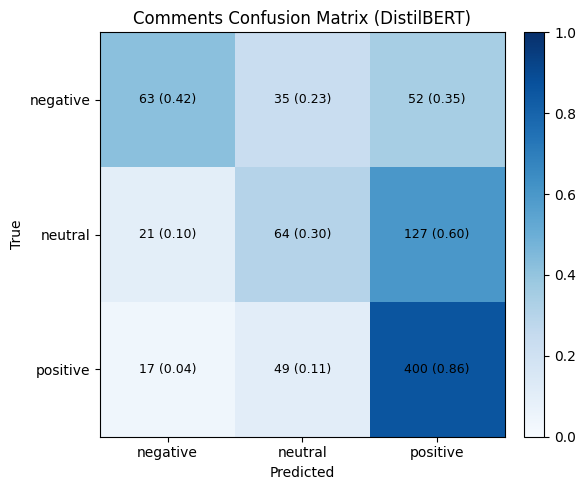

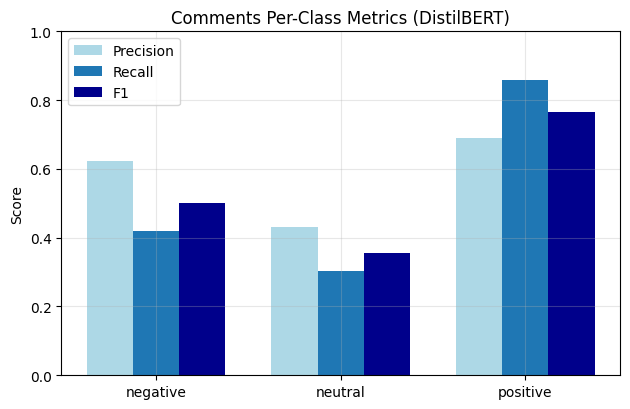

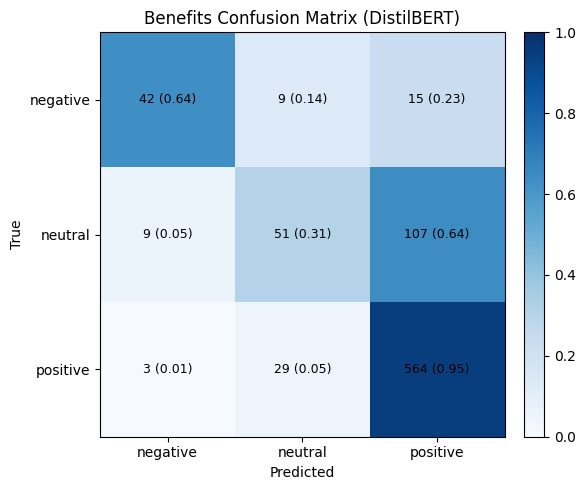

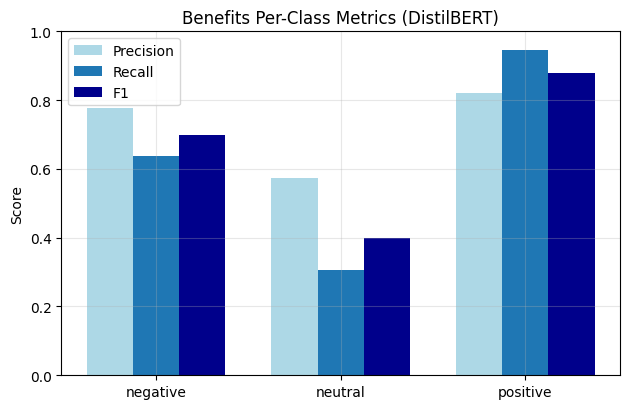

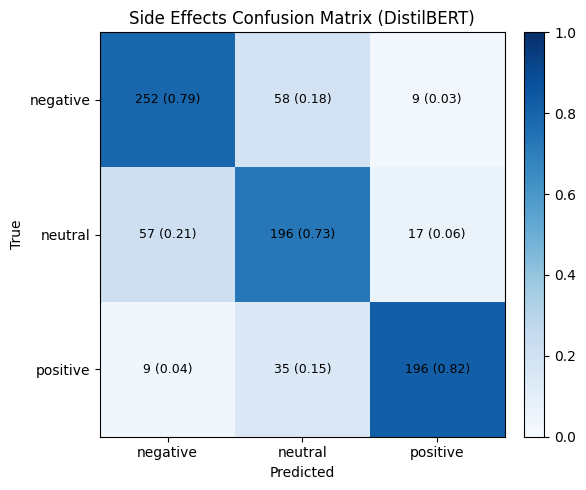

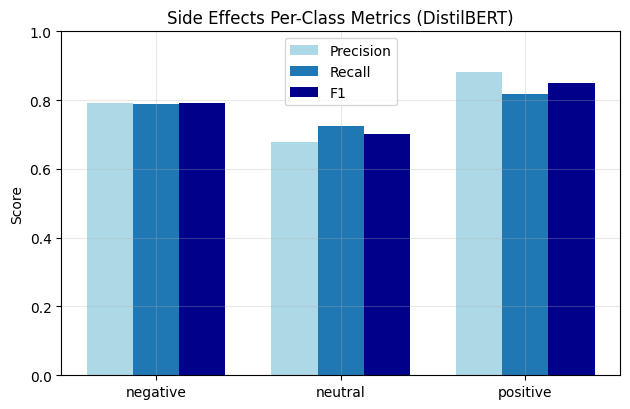

In [ ]:
# ---------- Per-aspect visuals + metrics ----------
summary_rows = []
for sec in ASPECTS:
    mask = (test_df["aspect"] == sec).values
    idxs = np.where(mask)[0].tolist()
    sub_ds   = hf_ds["test"].select(idxs)
    sub_out  = trainer.predict(sub_ds)
    y_true   = test_df.loc[mask, "label"].values
    y_pred   = np.argmax(sub_out.predictions, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    summary_rows.append({"Aspect": sec.title(), "Accuracy": acc, "Macro-F1": f1m})

    # Confusion matrix & per-class bars
    plot_confusion_matrix_pretty(y_true, y_pred, LABELS,
                                 title=f"{sec.title()} Confusion Matrix (DistilBERT)",
                                 normalize="true")
    plot_per_class_bars(y_true, y_pred, LABELS,
                        title=f"{sec.title()} Per-Class Metrics (DistilBERT)")

,Aspect,Accuracy,Macro-F1
0,Comments,0.6365,0.5410
1,Benefits,0.7925,0.6594
2,Side Effects,0.7768,0.7803


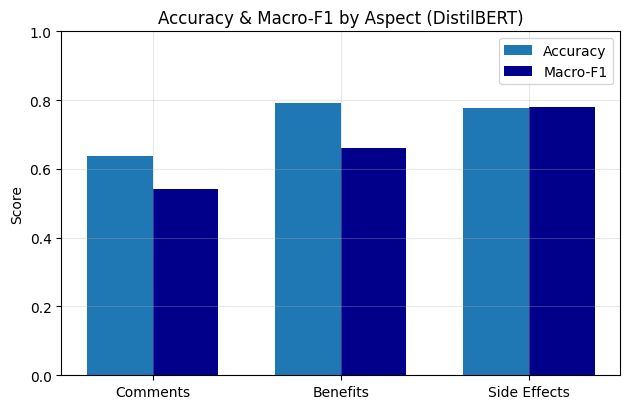

In [ ]:
# ---------- Summary bar chart: Accuracy & Macro-F1 by aspect ----------
summary_df = pd.DataFrame(summary_rows)
display(summary_df.style.format({"Accuracy":"{:.4f}", "Macro-F1":"{:.4f}"}))

x = np.arange(len(summary_df))
w = 0.35
fig, ax = plt.subplots()
ax.bar(x - w/2, summary_df["Accuracy"].values,  width=w, label="Accuracy")
ax.bar(x + w/2, summary_df["Macro-F1"].values, width=w, label="Macro-F1", color="darkblue")
ax.set_xticks(x); ax.set_xticklabels(summary_df["Aspect"].values)
ax.set_ylim(0, 1.0); ax.set_ylabel("Score")
ax.set_title("Accuracy & Macro-F1 by Aspect (DistilBERT)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "summary_accuracy_macroF1_by_aspect.png"), dpi=600)
plt.grid(True, alpha=0.3)
plt.show()


Training Curve

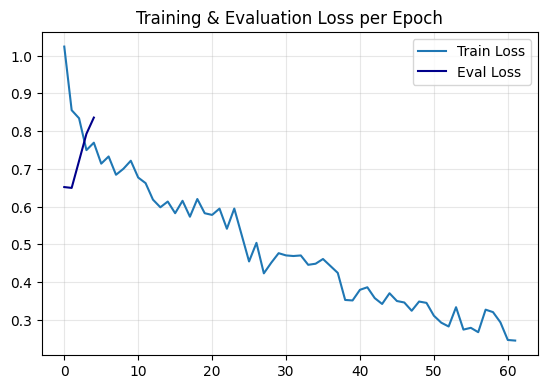

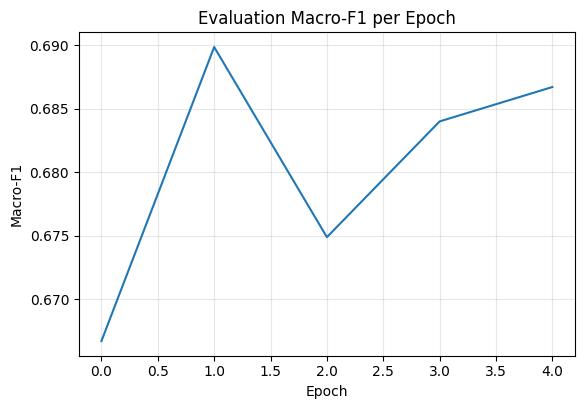

In [ ]:
from transformers.trainer_callback import TrainerCallback
trainer.state.log_history[:5]  # peek at logs

# Simple training/eval loss plot
logs = trainer.state.log_history
train_loss = [x["loss"] for x in logs if "loss" in x]
eval_loss  = [x["eval_loss"] for x in logs if "eval_loss" in x]
eval_f1    = [x.get("eval_f1_macro", None) for x in logs if "eval_f1_macro" in x]

plt.plot(train_loss, label="Train Loss")
plt.plot(eval_loss, label="Eval Loss" , color="darkblue")
plt.title("Training & Evaluation Loss per Epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.plot(eval_f1)
plt.title("Evaluation Macro-F1 per Epoch")
plt.ylabel("Macro-F1"); plt.xlabel("Epoch")
plt.grid(True, alpha=0.3)
plt.show()
